# TCCT S90 - Blind Intervention-Algebra Test

The S87D decoder and all TCCT mechanisms remain frozen. S90 uses an unseen nine-branch grammar and depths 73/121 to test identity, inverse, composition, path independence, and unaffected-query invariance.

The protocol is hashed before case generation. No training, search, decoder editing, or retuning is performed. Expected workload: 1,296 worlds. Run once and preserve either success or failure.


Dataset[{<|Stage -> S86, Name -> ExternalSixBranchBlind, CandidateFileLoaded -> True, 
 
>     CandidateHash -> a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     ExpectedCandidateHash -> 
 
>      a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     CandidateK -> 19, CandidatePolicyLength -> 26, 
 
>     OriginalFrozenModelChanged -> False, FrozenCandidateChanged -> False, 
 
>     CoreChanged -> False, PreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, CandidateFileLoaded, 
 
>      CandidateHash, ExpectedCandidateHash, CandidateK, CandidatePolicyLength, 
 
>      OriginalFrozenModelChanged, FrozenCandidateChanged, CoreChanged, PreflightPassed}\
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
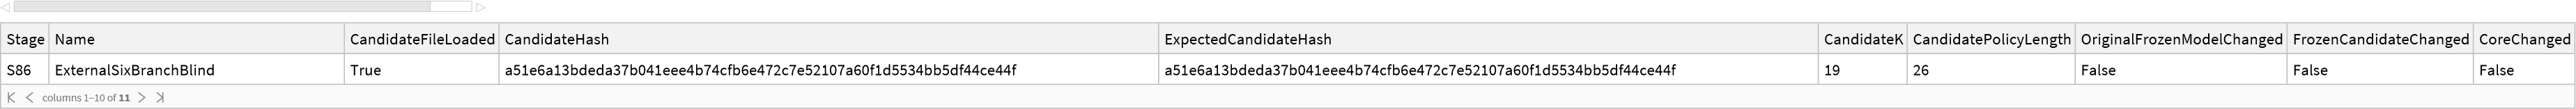

In [568]:
ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8661d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];

ClearAll[ChainIn63, SharedMerge63, Case63];
ChainIn63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, inc, rm, add, new, n},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
inc=Cases[
e,
DirectedEdge[u_, v_ ] /; MemberQ[f, v]:>{u, v}
];
rm=DirectedEdge@@@inc;
add=Flatten[
Table[
n=mx+i;
{
DirectedEdge[inc[[i, 1]], n],
DirectedEdge[n, inc[[i, 2]]]
},
{i, Length[inc]}
],
1
];
new=Union[
Join[
Complement[e, rm],
add
]
];
{{new, x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
SharedMerge63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, ps, rm, g, i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>u
];
rm=(DirectedEdge[#, m]&)/@ps;
new=Complement[
new,
rm
];
g=mx+i;
new=Join[
new,
(DirectedEdge[#, g]&)/@ps,
{DirectedEdge[g, m]}
],
{i, Length[f]}
];
{{Union[new], x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
Case63[
g_String ,
d_Integer,
a_Integer,
t_String
]:=
Switch[
g,
"ChainIn",
ChainIn63[Case59[d, a, t]],
"SharedMerge",
SharedMerge63[Case59[d, a, t]]
];

ClearAll[ParallelIn71];
ParallelIn71[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, incs, rm,
add, next, g1, g2, i, j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>{u, v}
];
rm=DirectedEdge@@@incs;
add= {};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[incs[[j, 1]], g1],
DirectedEdge[g1, m],
DirectedEdge[incs[[j, 1]], g2],
DirectedEdge[g2, m]
}
],
{j, Length[incs]}
];
new=Join[
Complement[new, rm],
add
],
{i, Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
}, a}
];

(* In[410] *)
ClearAll[Case71];
Case71[
d_Integer,
a_Integer,
t_String
]:=
ParallelIn71[
Case59[d, a, t]
];

ClearAll[ParallelOut72,SharedParallelIn72,Case72B];
ParallelOut72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,outs,rm,
add,g1,g2,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
outs=Cases[
new,
DirectedEdge[u_,v_]/;u===m:>{u,v}
];
rm=DirectedEdge@@@outs;
add={};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[m,g1],
DirectedEdge[g1,outs[[j,2]]],
DirectedEdge[m,g2],
DirectedEdge[g2,outs[[j,2]]]
}
],
{j,Length[outs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

SharedParallelIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,ps,rm,
g1,g2,add,i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>u
];
rm=(DirectedEdge[#,m]&)/@ps;
g1=next;
g2=next+1;
next=next+2;
add=Join[
Flatten[
Table[
{
DirectedEdge[ps[[j]],g1],
DirectedEdge[ps[[j]],g2]
},
{j,Length[ps]}
],
1
],
{
DirectedEdge[g1,m],
DirectedEdge[g2,m]
}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

Case72B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"ParallelOut",
ParallelOut72[Case59[depth,answer,target]],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"SharedParallelIn",
SharedParallelIn72[Case59[depth,answer,target]],
_,
$Failed
];



ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];ClearAll[
LocalMediatorSources82,
FullSemanticPatch82,
LocalMediatorPatch82,
PatchSourceSet82,
ReferenceAction82
];

LocalMediatorSources82[c_List]:=Module[
{x=c[[1]],answer=c[[2]],m},
m=x[[6,answer]];
{m,m+1,m+2}
];

FullSemanticPatch82[
depth_Integer,
answer_Integer
]:=EdgePatch81[
Case59[depth,answer,"Continue"],
Case59[depth,answer,"Stop"]
];

LocalMediatorPatch82[
depth_Integer,
answer_Integer
]:=Module[
{factual,fullPatch,sources},
factual=Case59[depth,answer,"Continue"];
fullPatch=FullSemanticPatch82[depth,answer];
sources=LocalMediatorSources82[factual];
<|
"Remove"->Select[
fullPatch["Remove"],
MemberQ[sources,#[[1]]]&
],
"Add"->Select[
fullPatch["Add"],
MemberQ[sources,#[[1]]]&
]
|>
];

PatchSourceSet82[patch_Association]:=Union[
Map[First,patch["Remove"]],
Map[First,patch["Add"]]
];

ReferenceAction82[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],e,m,safe,u,dum,
correct,wrong,continueEdges,stopEdges
},
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dum=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dum]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],
"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],
"Stop",
True,
"Undefined"
]
];

interventionImplementationHash82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];expectedMinimalKernelDefinitionTextHash86=
"d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922";
expectedCanonicalizerHash86=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedStableFrozenArchitectureHash86=
"d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d";
expectedInterventionHash86=
"45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf";
expectedCandidateHash86=
"a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f";

candidateSnapshotPath86=
"E:/engine_wolf/TCCT_S83B_FrozenCandidate.wl";

If[
!FileExistsQ[candidateSnapshotPath86],
Print["S86 aborted: frozen S83B candidate file is missing."];
Abort[]
];

Get[candidateSnapshotPath86];

ClearAll[CoreDefinitionBundle86];
CoreDefinitionBundle86[]:={
DownValues[P59],DownValues[A59],DownValues[T59],DownValues[Case59],
OwnValues[rw60],DownValues[Pack60],DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],DownValues[EncodeRows75],
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],DownValues[Case79]
};

minimalKernelDefinitionTextHash86=Hash[
ToString[InputForm[CoreDefinitionBundle86[]]],
"SHA256","HexString"
];

stableFrozenArchitectureHash86=Hash[
{
Normal[frozen75D],
minimalKernelDefinitionTextHash86,
canonicalizerImplementationHash79B
},
"SHA256","HexString"
];

candidateHashLoaded86=If[
AssociationQ[frozenCandidate83B],
Hash[Normal[frozenCandidate83B],"SHA256","HexString"],
Missing["CandidateNotLoaded"]
];

preflightPassed86=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelDefinitionTextHash86,
expectedMinimalKernelDefinitionTextHash86
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash86
],
SameQ[
stableFrozenArchitectureHash86,
expectedStableFrozenArchitectureHash86
],
SameQ[interventionImplementationHash82,expectedInterventionHash86],
AssociationQ[frozenCandidate83B],
SameQ[candidateHashLoaded86,expectedCandidateHash86],
SameQ[frozenCandidate83B["BaseFrozenModelHash"],expectedFrozenModelHash79A],
SameQ[frozenCandidate83B["EncoderParams"],frozen75D["Params"]],
SameQ[frozenCandidate83B["Representation"],"KExactRole"],
SameQ[frozenCandidate83B["K"],19],
SameQ[Length[frozenCandidate83B["Policy"]],26],
SameQ[frozenCandidate83B["DevelopmentScore"],264],
TrueQ[frozenCandidate83B["ExactNodeRoleUsed"]],
TrueQ[frozenCandidate83B["FrozenBeforeS84"]]
];

preflight86=<|
"Stage"->"S86",
"Name"->"ExternalSixBranchBlind",
"CandidateFileLoaded"->FileExistsQ[candidateSnapshotPath86],
"CandidateHash"->candidateHashLoaded86,
"ExpectedCandidateHash"->expectedCandidateHash86,
"CandidateK"->If[AssociationQ[frozenCandidate83B],frozenCandidate83B["K"],Missing[]],
"CandidatePolicyLength"->If[
AssociationQ[frozenCandidate83B],Length[frozenCandidate83B["Policy"]],Missing[]
],
"OriginalFrozenModelChanged"->False,
"FrozenCandidateChanged"->False,
"CoreChanged"->False,
"PreflightPassed"->preflightPassed86
|>;

If[
!TrueQ[preflightPassed86],
Print[Dataset[{preflight86}]];
Print["S86 aborted: frozen architecture or S83B candidate mismatch."];
Abort[]
];

Dataset[{preflight86}]


Dataset[{<|Stage -> S90, Name -> InterventionAlgebraBlind, 
 
>     CandidateFrozenBeforeProtocol -> True, 
 
>     DecoderCandidateHash -> 
 
>      703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     DecoderCandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     FeatureRuntimeFileHash -> 
 
>      7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee, 
 
>     K33CandidateHash -> 
 
>      2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, 
 
>     FeatureFamily -> QueriedGlobalMoments, FeatureDimension -> 27, BranchCount -> 9, 
 
>     Depths -> {73, 121}, TrainingRun -> False, CandidateSearchRun -> False, 
 
>     DecoderEditApplied -> False, RetuningApplied -> False, 
 
>     S89CheckpointLocked -> True, S90ResultAlreadyPresent -> False, 
 
>     PreflightPassed -> True|>}, TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[
 
>      String], TypeSystem`AnyType, 18], 1], <||>]
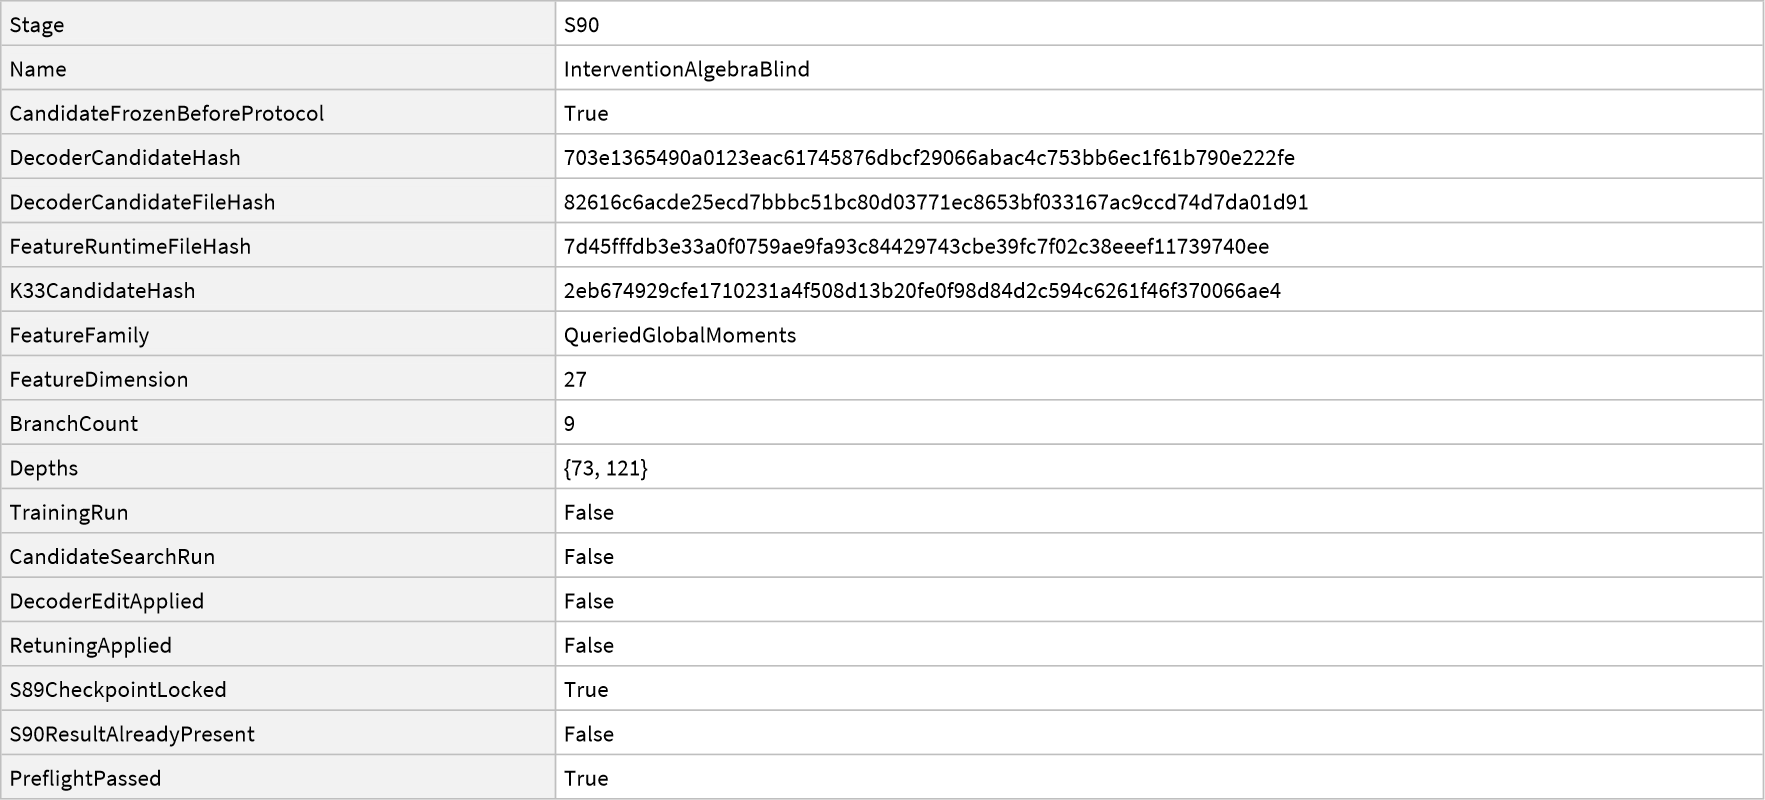

In [652]:
expectedFrozenModelHash90=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedK33CandidateHash90=
"2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4";
expectedK33CandidateFileHash90=
"4a252b8977101d024b1b2feb00b4626ca28290c3982cdad199bc78ef7e0c98f1";
expectedDecoderCandidateHash90=
"703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe";
expectedDecoderCandidateFileHash90=
"82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91";
expectedClassifierBinaryHash90=
"2b8861c03c8169571061a85c12644c6e30a11e8f8f15f5c69c6761215f4752f1";
expectedFeatureRuntimeFileHash90=
"7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee";
expectedFreezeProtocolHash90=
"03d7a40eefdaec9d9fce599517d3663ba381d50218bfe4934580bd22ca31b86c";
expectedFreezeCertificateFileHash90=
"7c83717fc5bf50b1bde853401da8d0fc5931d6b1b23663d75777e1e45516fb8e";
expectedS89CheckpointFileHash90=
"7d0f543f6f17384ee8969131547b2766aad1fbaed999e5b039c2708d6d89b032";

k33CandidatePath90="E:/engine_wolf/TCCT_S86E_K33FrozenCandidate.wl";
decoderRuntimePath90="E:/engine_wolf/TCCT_S87D_FrozenDecoderRuntime.wl";
decoderCandidatePath90=
"E:/engine_wolf/TCCT_S87D_FrozenWorldMultisetDecoder.wxf";
freezeCertificatePath90="E:/engine_wolf/TCCT_S87D_FreezeCertificate.json";
s89CheckpointPath90="E:/engine_wolf/TCCT_S89_BlindResultCertificate.json";
s90ResultCertificatePath=
"E:/engine_wolf/TCCT_S90_BlindResultCertificate.json";

ClearAll[FileSHA256Hex90];
FileSHA256Hex90[path_String]:=If[
FileExistsQ[path],
IntegerString[FileHash[path,"SHA256"],16,64],
Missing["FileMissing",path]
];

requiredFilesPresent90=And@@Map[
FileExistsQ,
{
k33CandidatePath90,decoderRuntimePath90,
decoderCandidatePath90,freezeCertificatePath90,s89CheckpointPath90
}
];

If[
!TrueQ[requiredFilesPresent90],
Print["S90 aborted: one or more frozen input files are missing."];
Abort[]
];

If[
FileExistsQ[s90ResultCertificatePath],
Print["S90 aborted: a prior S90 result certificate already exists."];
Print["Preserve the prior blind result; do not overwrite or retune."];
Abort[]
];

k33CandidateFileHashBefore90=FileSHA256Hex90[k33CandidatePath90];
decoderRuntimeFileHashBefore90=FileSHA256Hex90[decoderRuntimePath90];
decoderCandidateFileHashBefore90=FileSHA256Hex90[decoderCandidatePath90];
freezeCertificateFileHashBefore90=FileSHA256Hex90[freezeCertificatePath90];
s89CheckpointFileHashBefore90=FileSHA256Hex90[s89CheckpointPath90];

Clear[frozenCandidate86E];
Get[k33CandidatePath90];
k33CandidateHashLoaded90=If[
AssociationQ[frozenCandidate86E],
Hash[Normal[frozenCandidate86E],"SHA256","HexString"],
Missing["K33CandidateNotLoaded"]
];

Get[decoderRuntimePath90];
frozenDecoderLoaded90=TCCTLoadFrozenDecoderS87D[decoderCandidatePath90];
frozenDecoderRaw90=If[
AssociationQ[frozenDecoderLoaded90],
KeyDrop[frozenDecoderLoaded90,{"Classifier"}],
$Failed
];
decoderCandidateHashLoaded90=If[
AssociationQ[frozenDecoderRaw90],
Lookup[frozenDecoderRaw90,"CandidateHash",Missing["CandidateHashMissing"]],
Missing["DecoderNotLoaded"]
];
decoderPayloadHashLoaded90=If[
AssociationQ[frozenDecoderRaw90],
Hash[
Normal[KeyDrop[frozenDecoderRaw90,{"CandidateHash"}]],
"SHA256","HexString"
],
Missing["DecoderNotLoaded"]
];

freezeCertificate90=Quiet@Check[
Import[freezeCertificatePath90,"RawJSON"],
$Failed
];

s89Checkpoint90=Quiet@Check[
Import[s89CheckpointPath90,"RawJSON"],
$Failed
];

ClearAll[CoreDefinitionBundle90];
CoreDefinitionBundle90[]:=CoreDefinitionBundle86[];

modelHashBefore90=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashBefore90=Hash[
Normal[frozenCandidate86E],"SHA256","HexString"
];
decoderObjectHashBefore90=If[
AssociationQ[frozenDecoderRaw90],
Hash[Normal[frozenDecoderRaw90],"SHA256","HexString"],
Missing["DecoderNotLoaded"]
];
coreHashBefore90=Hash[CoreDefinitionBundle90[],"SHA256","HexString"];
canonicalizerHashBefore90=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256","HexString"
];
interventionHashBefore90=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256","HexString"
];
topologyPrimitiveHashBefore90=Hash[
{
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[HierarchicalDiamondIn80]
},
"SHA256","HexString"
];
decoderRuntimeDefinitionHashBefore90=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"
];

preflightPassed90=And[
TrueQ[preflightPassed86],
SameQ[modelHashBefore90,expectedFrozenModelHash90],
AssociationQ[frozenCandidate86E],
SameQ[k33CandidateHashLoaded90,expectedK33CandidateHash90],
SameQ[k33CandidateFileHashBefore90,expectedK33CandidateFileHash90],
SameQ[frozenCandidate86E["K"],33],
SameQ[frozenCandidate86E["Representation"],"KExactRole"],
AssociationQ[frozenDecoderLoaded90],
AssociationQ[frozenDecoderRaw90],
Head[frozenDecoderLoaded90["Classifier"]]===ClassifierFunction,
SameQ[decoderCandidateHashLoaded90,expectedDecoderCandidateHash90],
SameQ[decoderPayloadHashLoaded90,expectedDecoderCandidateHash90],
SameQ[decoderCandidateFileHashBefore90,expectedDecoderCandidateFileHash90],
SameQ[decoderRuntimeFileHashBefore90,expectedFeatureRuntimeFileHash90],
SameQ[frozenDecoderRaw90["ClassifierBinaryHash"],
expectedClassifierBinaryHash90],
SameQ[frozenDecoderRaw90["FeatureRuntimeFileHash"],
FileHash[decoderRuntimePath90,"SHA256"]],
SameQ[frozenDecoderRaw90["ProtocolHash"],expectedFreezeProtocolHash90],
SameQ[frozenDecoderRaw90["FeatureFamily"],"QueriedGlobalMoments"],
SameQ[frozenDecoderRaw90["FeatureDimension"],27],
SameQ[Length[frozenDecoderRaw90["FeatureNames"]],27],
SameQ[frozenDecoderRaw90["K"],33],
SameQ[frozenDecoderRaw90["BaseFrozenModelHash"],
expectedFrozenModelHash90],
SameQ[frozenDecoderRaw90["BaseK33CandidateHash"],
expectedK33CandidateHash90],
TrueQ[frozenDecoderRaw90["FrozenBeforeS88"]],
TrueQ[frozenDecoderRaw90["S88DataReadBeforeFreeze"]===False],
AssociationQ[freezeCertificate90],
SameQ[freezeCertificateFileHashBefore90,
expectedFreezeCertificateFileHash90],
TrueQ[freezeCertificate90["FreezeValidityPassed"]],
TrueQ[freezeCertificate90["ReadyForS88"]],
SameQ[freezeCertificate90["CandidateHash"],
expectedDecoderCandidateHash90],
SameQ[freezeCertificate90["Outcome"],
"S87D_DECODER_FROZEN_AND_LOCKED_READY_FOR_S88"],
TrueQ[freezeCertificate90["CoreChanged"]===False],
TrueQ[freezeCertificate90["S88DataReadBeforeFreeze"]===False],
AssociationQ[s89Checkpoint90],
SameQ[s89CheckpointFileHashBefore90,expectedS89CheckpointFileHash90],
SameQ[s89Checkpoint90["Stage"],"S89"],
TrueQ[s89Checkpoint90["TestValidityPassed"]],
TrueQ[s89Checkpoint90["BlindPerfect"]],
SameQ[s89Checkpoint90["Outcome"],
"S89_BLIND_STOP_RELOCATION_PASS"],
!FileExistsQ[s90ResultCertificatePath]
];

preflight90=<|
"Stage"->"S90",
"Name"->"InterventionAlgebraBlind",
"CandidateFrozenBeforeProtocol"->True,
"DecoderCandidateHash"->decoderCandidateHashLoaded90,
"DecoderCandidateFileHash"->decoderCandidateFileHashBefore90,
"FeatureRuntimeFileHash"->decoderRuntimeFileHashBefore90,
"K33CandidateHash"->k33CandidateHashLoaded90,
"FeatureFamily"->If[
AssociationQ[frozenDecoderRaw90],
frozenDecoderRaw90["FeatureFamily"],Missing[]
],
"FeatureDimension"->If[
AssociationQ[frozenDecoderRaw90],
frozenDecoderRaw90["FeatureDimension"],Missing[]
],
"BranchCount"->9,
"Depths"->{73,121},
"TrainingRun"->False,
"CandidateSearchRun"->False,
"DecoderEditApplied"->False,
"RetuningApplied"->False,
"S89CheckpointLocked"->And[
SameQ[s89CheckpointFileHashBefore90,expectedS89CheckpointFileHash90],
TrueQ[s89Checkpoint90["BlindPerfect"]]
],
"S90ResultAlreadyPresent"->FileExistsQ[s90ResultCertificatePath],
"PreflightPassed"->preflightPassed90
|>;

If[
!TrueQ[preflightPassed90],
Print[Dataset[{preflight90}]];
Print["S90 aborted: frozen decoder, architecture, or file lock mismatch."];
Abort[]
];

Dataset[{preflight90}]


Dataset[{<|Stage -> S90, Name -> InterventionAlgebraBlind, 
 
>     Candidate -> S87D-FrozenWorldMultisetDecoder, 
 
>     CandidateHash -> 703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     CandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     FeatureRuntimeFileHash -> 
 
>      7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee, 
 
>     K33CandidateHash -> 
 
>      2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, 
 
>     S89CheckpointFileHash -> 
 
>      7d0f543f6f17384ee8969131547b2766aad1fbaed999e5b039c2708d6d89b032, 
 
>     BranchCount -> 9, Depths -> {73, 121}, 
 
>     Topologies -> {TripleSerialDiamondIn, HierarchicalTerminalDiamondIn}, 
 
>     TopologySpecHash -> 
 
>      bd903aeb069a3acbffbaf7013f1161cc97c8c922e6cde78368e4e7aeb83659de, 
 
>     AlgebraTuples -> 
 
>      {{1, 3, 6, 8}, {2, 4, 7, 9}, {3, 5, 8, 1}, {4, 6, 9, 2}, {5, 7, 1, 3}, 
 
>       {6, 8, 2, 4}, {7, 9, 3, 5}, {8, 1, 4, 6}, {9, 2, 5, 7}}, 
 
>     ExpectedScenarios -> 36, ExpectedWorlds -> 1296, ExpectedContinueWorlds -> 1152, 
 
>     ExpectedStopWorlds -> 144, ExpectedUnaffectedQueryRelations -> 180, 
 
>     ExternalGrammar -> IndependentNineBranchT90, 
 
>     InterventionAlgebra -> {Identity, Inverse, Composition, PathIndependence}, 
 
>     StateSemantics -> ExactlyOneStopAcrossA_B_C_D, 
 
>     QueryGrid -> AllNineQueriesAtFourAlgebraEndpoints, 
 
>     FeatureFamily -> QueriedGlobalMoments, FeatureDimension -> 27, 
 
>     ObservationAggregation -> FullQueriedObservationMultisetWithoutCodeDeduplication, 
 
>     LegacyTokenDeduplication -> DeleteDuplicatesAfterExactRoleCodePairing, 
 
>     SuccessCriterion -> ValidAlgebraHarnessAndAll1296EndpointWorldsCorrect, 
 
>     CandidateFrozenBeforeProtocol -> True, S89CheckpointReadOnlyLock -> True, 
 
>     S89PredictionsUsedForSelection -> False, TrainingRun -> False, 
 
>     CandidateSearchRun -> False, DecoderEditApplied -> False, 
 
>     RetuningApplied -> False, NoCaseEvaluatedBeforeProtocolHash -> True, 
 
>     ProtocolHash -> ed241ba2ada54af6e44f9dc009a70f4155767de6994072c7c05e5b75515df518, 
 
>     TestDefinitionHash -> 
 
>      ef31b96fa3a1ff1b4c7f4aec17456d60ec3381eca4df7f6ee8b9bf25f320539c|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 37], 
 
>    1], <||>]
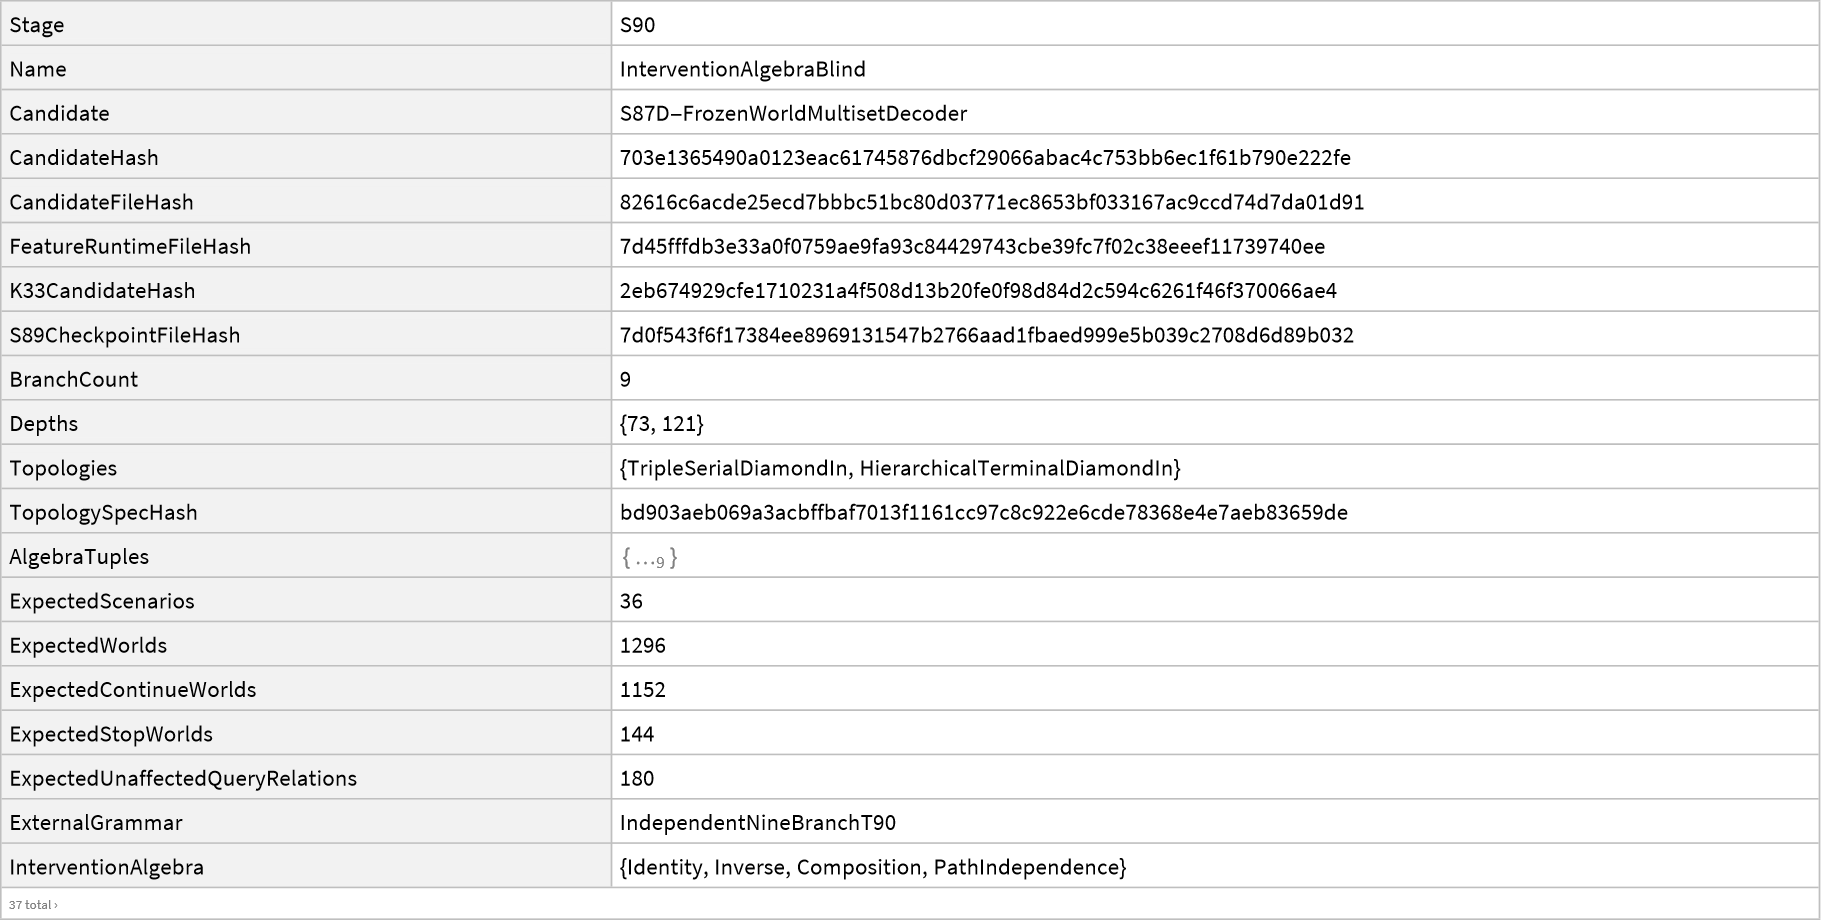

In [706]:
ClearAll[
T90,
Case90,
ReferenceAction90,
NodeRole90,
EncodePair90,
LegacyPredictTokens90,
PredictFrozenDecoder90,
TripleSerialDiamondIn90,
HierarchicalTerminalDiamondIn90,
SetAnswer90,
TopologyTransform90,
ExpectedContractions90,
BranchStopPatch90,
BranchContinuePatch90,
StopRelocationPatch90,
IdentityPatch90,
PrepareWorld90,
PrepareScenario90,
S90TestDefinitionBundle
];


T90[
depth_Integer,
target_String,
answer_Integer,
seed_Integer,
branchCount_Integer
]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dummy,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,branchCount}];
v=Table[bb+200+i,{i,branchCount}];
q=Table[bb+300+i,{i,branchCount}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,branchCount}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dummy=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,branchCount]]];
main=Join[
P59[q[[i]],r1,depth,ib+1000000],
P59[q[[i]],r2,depth,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,depth+1,ib+3000000]
];
perm=If[
target==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dummy]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,branchCount}
];
{{Union[e],q,K,v,c,f},answer}
];

Case90[depth_Integer,answer_Integer,target_String]:=
T90[depth,target,answer,90000000+100 depth,9];

ReferenceAction90[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],branchCount,e,m,safe,u,dummy,
correct,wrong,continueEdges,stopEdges
},
branchCount=Length[x[[6]]];
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dummy=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,branchCount]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dummy]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],"Stop",
True,"Undefined"
]
];

NodeRole90[originalNode_,case_List,answer_Integer]:=Module[
{x,branchCount,m,correct,wrong,dummy,querySources,queryBranch,role},
x=case[[1]];
branchCount=Length[x[[6]]];
m=x[[6,answer]];
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,branchCount]]];
dummy=m+3;
querySources={m,m+1,m+2};
queryBranch=Union[querySources,{correct,wrong,dummy}];
role=Which[
SameQ[originalNode,m],"QueriedDecision",
MemberQ[querySources,originalNode],"QueriedMediatorSource",
SameQ[originalNode,correct],"QueriedCorrectDestination",
SameQ[originalNode,wrong],"QueriedWrongDestination",
SameQ[originalNode,dummy],"QueriedDummyDestination",
MemberQ[x[[6]],originalNode],"OtherDecision",
MemberQ[x[[5]],originalNode],"OtherAnswerDestination",
True,"OtherReject"
];
<|
"Role"->role,
"QueryBranchRelated"->MemberQ[queryBranch,originalNode]
|>
];

EncodePair90[pair_List]:=Module[{encoded},
encoded=First@EncodeRows75[
{<|
"Grammar"->"S90BlindObservation",
"Depth"->0,"Answer"->0,"Target"->"Unlabeled",
"StatePairs"->{pair}
|>},
frozenCandidate86E["EncoderParams"],
frozenCandidate86E["K"]
];
First[encoded["Codes"]]
];

LegacyPredictTokens90[tokens_List]:=If[
AnyTrue[tokens,MemberQ[frozenCandidate86E["Policy"],#]&],
"Continue",
"Stop"
];

PredictFrozenDecoder90[observations_List]:=Module[{probe,prediction},
probe=<|"Observations"->observations|>;
prediction=TCCTPredictWorldS87D[probe,frozenDecoderLoaded90];
If[MemberQ[{"Continue","Stop"},prediction],prediction,$Failed]
];

SetAnswer90[c_List,answer_Integer]:={c[[1]],answer};

TripleSerialDiamondIn90[c_List]:=
DiamondIn72[DoubleDiamondIn79[c]];

HierarchicalTerminalDiamondIn90[c_List]:=
DiamondIn72[HierarchicalDiamondIn80[c]];

TopologyTransform90[topology_String,c_List]:=Switch[
topology,
"TripleSerialDiamondIn",TripleSerialDiamondIn90[c],
"HierarchicalTerminalDiamondIn",HierarchicalTerminalDiamondIn90[c],
_,$Failed
];

ExpectedContractions90[topology_String,baseCase_List]:=Switch[
topology,
"TripleSerialDiamondIn",3 DecisionIncomingEdgeCount79B[baseCase],
"HierarchicalTerminalDiamondIn",4 DecisionIncomingEdgeCount79B[baseCase],
_,Missing["UnknownTopology"]
];


BranchStopPatch90[c_List,branch_Integer]:=Module[
{x,branchCount,e,m,safe,u,dummy,correct,wrong,remove,add},
x=c[[1]];
branchCount=Length[x[[6]]];
e=x[[1]];
m=x[[6,branch]];
safe=m+1;
u=m+2;
dummy=m+3;
correct=x[[5,branch]];
wrong=x[[5,1+Mod[branch,branchCount]]];
remove={
DirectedEdge[m,correct],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
};
add={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dummy]
};
<|
"Remove"->remove,
"Add"->add,
"ValidOnInput"->And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
]
|>
];

BranchContinuePatch90[c_List,branch_Integer]:=Module[
{x,branchCount,e,m,safe,u,dummy,correct,wrong,remove,add},
x=c[[1]];
branchCount=Length[x[[6]]];
e=x[[1]];
m=x[[6,branch]];
safe=m+1;
u=m+2;
dummy=m+3;
correct=x[[5,branch]];
wrong=x[[5,1+Mod[branch,branchCount]]];
remove={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dummy]
};
add={
DirectedEdge[m,correct],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
};
<|
"Remove"->remove,
"Add"->add,
"ValidOnInput"->And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
]
|>
];

StopRelocationPatch90[c_List,algebraTuple_List]:=Module[
{fromBranch,toBranch,restorePart,stopPart,remove,add},
fromBranch=First[algebraTuple];
toBranch=Last[algebraTuple];
restorePart=BranchContinuePatch90[c,fromBranch];
stopPart=BranchStopPatch90[c,toBranch];
remove=DeleteDuplicates@Join[restorePart["Remove"],stopPart["Remove"]];
add=DeleteDuplicates@Join[restorePart["Add"],stopPart["Add"]];
<|
"Remove"->remove,
"Add"->add,
"FromBranch"->fromBranch,
"ToBranch"->toBranch,
"DistinctBranches"->UnsameQ[fromBranch,toBranch],
"ComponentPatchesValid"->And[
TrueQ[restorePart["ValidOnInput"]],TrueQ[stopPart["ValidOnInput"]]
],
"NoCrossBranchConflict"->Intersection[remove,add]==={},
"ExpectedEditCount"->And[Length[remove]===6,Length[add]===6]
|>
];


IdentityPatch90[c_List]:=<|
"Remove"->{},
"Add"->{},
"ValidOnInput"->ListQ[c]
|>;

PrepareWorld90[
topology_String,
depth_Integer,
algebraTuple_List,
graphCondition_String,
answer_Integer,
target_String,
baseCase_List
]:=Module[
{
topologyCase,canonicalization,canonicalCase,expectedContractions,
traceSeconds,trace,levels,pack,vertexList,packedNodes,
observations,originalNode,pair,roleInfo,rawTokens,tokens,featureVector,legacyPrediction,prediction
},
topologyCase=TopologyTransform90[topology,baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
expectedContractions=ExpectedContractions90[topology,baseCase];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];
pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[
Length[trace["Rejects"]]===0,
{},
DeleteDuplicates[trace["Rejects"][[All,2]]]
];
observations=Map[
Function[packedNode,
originalNode=vertexList[[packedNode]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
roleInfo=NodeRole90[originalNode,canonicalCase,answer];
<|
"Role"->roleInfo["Role"],
"QueryBranchRelated"->roleInfo["QueryBranchRelated"],
"Code"->EncodePair90[pair]
|>
],
packedNodes
];
rawTokens=({#1["Role"],#1["Code"]}&)/@observations;
tokens=DeleteDuplicates[rawTokens];
featureVector=TCCTWorldVectorS87D[<|"Observations"->observations|>];
legacyPrediction=LegacyPredictTokens90[tokens];
prediction=PredictFrozenDecoder90[observations];
<|
"Topology"->topology,
"Depth"->depth,
"AlgebraTuple"->algebraTuple,
"GraphCondition"->graphCondition,
"Answer"->answer,
"Target"->target,
"ReferenceAction"->ReferenceAction90[canonicalCase],
"BranchCount"->Length[canonicalCase[[1,6]]],
"Prediction"->prediction,
"LegacyPrediction"->legacyPrediction,
"FeatureVector"->featureVector,
"Correct"->SameQ[prediction,target],
"TopologyGraphHash"->Hash[topologyCase[[1,1]],"SHA256","HexString"],
"CanonicalGraphHash"->Hash[canonicalCase[[1,1]],"SHA256","HexString"],
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"Contractions"->canonicalization["Contractions"],
"ExpectedContractions"->expectedContractions,
"ContractionCountCorrect"->SameQ[
canonicalization["Contractions"],expectedContractions
],
"ProtectedNodesPreserved"->canonicalization["ProtectedNodesPreserved"],
"StateObservationCount"->Length[observations],
"RawTokenCount"->Length[rawTokens],
"TokenCount"->Length[tokens],
"DuplicateTokensRemoved"->Length[rawTokens]-Length[tokens],
"LegacyPolicyHitTokens"->Intersection[tokens,frozenCandidate86E["Policy"]],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"Rounds"->trace["Rounds"],
"TraceSeconds"->traceSeconds
|>
];



PrepareScenario90[
topology_String,depth_Integer,algebraTuple_List
]:=Module[
{
branchCount=9,a,b,c,d,seedCase,startPatch,caseA,identityPatch,caseAIdentity,
patchAB,caseB,patchBA,caseARestored,patchAC,caseCDirect,
patchBC,caseCViaB,patchAD,caseD,patchDC,caseCViaD,
stateCases,stateStops,stateWorlds,unaffectedQueries,
allRelocations,allPatchesValid,allStatesSingleStop,
unaffectedPredictionInvariant,stateGraphGroups
},
{a,b,c,d}=algebraTuple;
seedCase=Case90[depth,1,"Continue"];
startPatch=BranchStopPatch90[seedCase,a];
caseA=ApplyEdgePatch81[seedCase,startPatch];
identityPatch=IdentityPatch90[caseA];
caseAIdentity=ApplyEdgePatch81[caseA,identityPatch];
patchAB=StopRelocationPatch90[caseA,{a,b}];
caseB=ApplyEdgePatch81[caseA,patchAB];
patchBA=StopRelocationPatch90[caseB,{b,a}];
caseARestored=ApplyEdgePatch81[caseB,patchBA];
patchAC=StopRelocationPatch90[caseA,{a,c}];
caseCDirect=ApplyEdgePatch81[caseA,patchAC];
patchBC=StopRelocationPatch90[caseB,{b,c}];
caseCViaB=ApplyEdgePatch81[caseB,patchBC];
patchAD=StopRelocationPatch90[caseA,{a,d}];
caseD=ApplyEdgePatch81[caseA,patchAD];
patchDC=StopRelocationPatch90[caseD,{d,c}];
caseCViaD=ApplyEdgePatch81[caseD,patchDC];
If[AnyTrue[
{caseA,caseAIdentity,caseB,caseARestored,caseCDirect,caseCViaB,caseD,caseCViaD},
SameQ[#,$Failed]&],Return[$Failed]];
allRelocations={patchAB,patchBA,patchAC,patchBC,patchAD,patchDC};
allPatchesValid=And[
TrueQ[startPatch["ValidOnInput"]],TrueQ[identityPatch["ValidOnInput"]],
And@@Map[And[
TrueQ[#1["DistinctBranches"]],TrueQ[#1["ComponentPatchesValid"]],
TrueQ[#1["NoCrossBranchConflict"]],TrueQ[#1["ExpectedEditCount"]]
]&,allRelocations]
];
stateCases=<|"A"->caseA,"B"->caseB,"C"->caseCDirect,"D"->caseD|>;
stateStops=<|"A"->a,"B"->b,"C"->c,"D"->d|>;
stateWorlds=Flatten[KeyValueMap[
Function[{label,worldCase},Table[
PrepareWorld90[
topology,depth,algebraTuple,"State"<>label,answer,
If[SameQ[answer,stateStops[label]],"Stop","Continue"],
SetAnswer90[worldCase,answer]
],{answer,Range[branchCount]}]],stateCases],1];
allStatesSingleStop=And@@KeyValueMap[
Function[{label,worldCase},SameQ[
Count[Table[ReferenceAction90[SetAnswer90[worldCase,q]],{q,Range[branchCount]}],"Stop"],1
]],stateCases];
unaffectedQueries=Complement[Range[branchCount],algebraTuple];
unaffectedPredictionInvariant=And@@Map[
Function[q,Module[{predictions},
predictions=Lookup[Select[stateWorlds,SameQ[#1["Answer"],q]&],"Prediction"];
And[Length[predictions]===4,SameQ@@predictions,SameQ[First[predictions],"Continue"]]
]],unaffectedQueries];
stateGraphGroups=GatherBy[stateWorlds,#1["GraphCondition"]&];
<|
"Topology"->topology,
"Depth"->depth,
"AlgebraTuple"->algebraTuple,
"TupleDistinct"->DuplicateFreeQ[algebraTuple],
"AllPatchesValid"->allPatchesValid,
"IdentityExact"->SameQ[caseAIdentity,caseA],
"InverseExact"->SameQ[caseARestored,caseA],
"CompositionExact"->SameQ[caseCViaB,caseCDirect],
"PathIndependenceExact"->SameQ[caseCViaD,caseCDirect],
"AllStatesSingleStop"->allStatesSingleStop,
"FourStateCasesDistinct"->DuplicateFreeQ[Values[stateCases]],
"AllStateGraphsSameAcrossQueries"->And@@Map[
SameQ@@Lookup[#,"TopologyGraphHash"]&,stateGraphGroups
],
"ReferenceActionsCorrect"->And@@Map[
SameQ[#1["ReferenceAction"],#1["Target"]]&,stateWorlds
],
"UnaffectedQueryCount"->Length[unaffectedQueries],
"UnaffectedPredictionInvariant"->unaffectedPredictionInvariant,
"AllThirtySixWorldsCorrect"->And@@Lookup[stateWorlds,"Correct"],
"Worlds"->stateWorlds
|>
];

S90TestDefinitionBundle[]:={
DownValues[T90],DownValues[Case90],DownValues[ReferenceAction90],
DownValues[NodeRole90],DownValues[EncodePair90],DownValues[LegacyPredictTokens90],
DownValues[PredictFrozenDecoder90],DownValues[TripleSerialDiamondIn90],
DownValues[HierarchicalTerminalDiamondIn90],DownValues[SetAnswer90],
DownValues[TopologyTransform90],DownValues[ExpectedContractions90],
DownValues[BranchStopPatch90],DownValues[BranchContinuePatch90],
DownValues[StopRelocationPatch90],DownValues[IdentityPatch90],
DownValues[PrepareWorld90],DownValues[PrepareScenario90]
};blindDepths90={73,121};
blindTopologies90={"TripleSerialDiamondIn","HierarchicalTerminalDiamondIn"};
blindAlgebraTuples90={
{1,3,6,8},{2,4,7,9},{3,5,8,1},{4,6,9,2},{5,7,1,3},
{6,8,2,4},{7,9,3,5},{8,1,4,6},{9,2,5,7}
};
topologySpec90=<|
"TripleSerialDiamondIn"->"DiamondIn72AfterDoubleDiamondIn79",
"HierarchicalTerminalDiamondIn"->"DiamondIn72AfterHierarchicalDiamondIn80"
|>;
topologySpecHash90=Hash[Normal[topologySpec90],"SHA256","HexString"];
testDefinitionHashBefore90=Hash[S90TestDefinitionBundle[],"SHA256","HexString"];
noCasesBeforeProtocolHash90=And[
!ValueQ[blindScenarios90],!ValueQ[blindWorlds90]
];
protocol90=<|
"Stage"->"S90",
"Name"->"InterventionAlgebraBlind",
"Candidate"->"S87D-FrozenWorldMultisetDecoder",
"CandidateHash"->decoderCandidateHashLoaded90,
"CandidateFileHash"->decoderCandidateFileHashBefore90,
"FeatureRuntimeFileHash"->decoderRuntimeFileHashBefore90,
"K33CandidateHash"->k33CandidateHashLoaded90,
"S89CheckpointFileHash"->s89CheckpointFileHashBefore90,
"BranchCount"->9,
"Depths"->blindDepths90,
"Topologies"->blindTopologies90,
"TopologySpecHash"->topologySpecHash90,
"AlgebraTuples"->blindAlgebraTuples90,
"ExpectedScenarios"->36,
"ExpectedWorlds"->1296,
"ExpectedContinueWorlds"->1152,
"ExpectedStopWorlds"->144,
"ExpectedUnaffectedQueryRelations"->180,
"ExternalGrammar"->"IndependentNineBranchT90",
"InterventionAlgebra"->{"Identity","Inverse","Composition","PathIndependence"},
"StateSemantics"->"ExactlyOneStopAcrossA_B_C_D",
"QueryGrid"->"AllNineQueriesAtFourAlgebraEndpoints",
"FeatureFamily"->"QueriedGlobalMoments",
"FeatureDimension"->27,
"ObservationAggregation"->"FullQueriedObservationMultisetWithoutCodeDeduplication",
"LegacyTokenDeduplication"->"DeleteDuplicatesAfterExactRoleCodePairing",
"SuccessCriterion"->"ValidAlgebraHarnessAndAll1296EndpointWorldsCorrect",
"CandidateFrozenBeforeProtocol"->True,
"S89CheckpointReadOnlyLock"->True,
"S89PredictionsUsedForSelection"->False,
"TrainingRun"->False,"CandidateSearchRun"->False,
"DecoderEditApplied"->False,"RetuningApplied"->False,
"NoCaseEvaluatedBeforeProtocolHash"->noCasesBeforeProtocolHash90
|>;
protocolHash90=Hash[Normal[protocol90],"SHA256","HexString"];
Dataset[{Join[protocol90,<|
"ProtocolHash"->protocolHash90,"TestDefinitionHash"->testDefinitionHashBefore90
|>]}]


Dataset[{<|Topology -> TripleSerialDiamondIn, Depth -> 73, AlgebraTuple -> {1, 3, 6, 8}, 
 
>     TupleDistinct -> True, AllPatchesValid -> True, IdentityExact -> True, 
 
>     InverseExact -> True, CompositionExact -> True, PathIndependenceExact -> True, 
 
>     AllStatesSingleStop -> True, UnaffectedPredictionInvariant -> True, 
 
>     AllThirtySixWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 73, AlgebraTuple -> {2, 4, 7, 9}, 
 
>     TupleDistinct -> True, AllPatchesValid -> True, IdentityExact -> True, 
 
>     InverseExact -> True, CompositionExact -> True, PathIndependenceExact -> True, 
 
>     AllStatesSingleStop -> True, UnaffectedPredictionInvariant -> True, 
 
>     AllThirtySixWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 73, AlgebraTuple -> {3, 5, 8, 1}, 
 
>     TupleDistinct -> True, AllPatchesValid -> True, IdentityExact -> True, 
 
>     InverseExact -> True, CompositionExact -> True, PathIndependenceExact -> True, 
 
>     AllStatesSingleStop -> True, UnaffectedPredictionInvariant -> True, 
 
>     AllThirtySixWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 73, AlgebraTuple -> {4, 6, 9, 2}, 
 
>     TupleDistinct -> True, AllPatchesValid -> True, IdentityExact -> True, 
 
>     InverseExact -> True, CompositionExact -> True, PathIndependenceExact -> True, 
 
>     AllStatesSingleStop -> True, UnaffectedPredictionInvariant -> True, 
 
>     AllThirtySixWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 73, AlgebraTuple -> {5, 7, 1, 3}, 
 
>     TupleDistinct -> True, AllPatchesValid -> True, IdentityExact -> True, 
 
>     InverseExact -> True, CompositionExact -> True, PathIndependenceExact -> True, 
 
>     AllStatesSingleStop -> True, UnaffectedPredictionInvariant -> True, 
 
>     AllThirtySixWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 73, AlgebraTuple -> {6, 8, 2, 4}, 
 
>     TupleDistinct -> True, AllPatchesValid -> True, IdentityExact -> True, 
 
>     InverseExact -> True, CompositionExact -> True, PathIndependenceExact -> True, 
 
>     AllStatesSingleStop -> True, UnaffectedPredictionInvariant -> True, 
 
>     AllThirtySixWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 73, AlgebraTuple -> {7, 9, 3, 5}, 
 
>     TupleDistinct -> True, AllPatchesValid -> True, IdentityExact -> True, 
 
>     InverseExact -> True, CompositionExact -> True, PathIndependenceExact -> True, 
 
>     AllStatesSingleStop -> True, UnaffectedPredictionInvariant -> True, 
 
>     AllThirtySixWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 73, AlgebraTuple -> {8, 1, 4, 6}, 
 
>     TupleDistinct -> True, AllPatchesValid -> True, IdentityExact -> True, 
 
>     InverseExact -> True, CompositionExact -> True, PathIndependenceExact -> True, 
 
>     AllStatesSingleStop -> True, UnaffectedPredictionInvariant -> True, 
 
>     AllThirtySixWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 73, AlgebraTuple -> {9, 2, 5, 7}, 
 
>     TupleDistinct -> True, AllPatchesValid -> True, IdentityExact -> True, 
 
>     InverseExact -> True, CompositionExact -> True, PathIndependenceExact -> True, 
 
>     AllStatesSingleStop -> True, UnaffectedPredictionInvariant -> True, 
 
>     AllThirtySixWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 121, AlgebraTuple -> {1, 3, 6, 8}, 
 
>     TupleDistinct -> True, AllPatchesValid -> True, IdentityExact -> True, 
 
>     InverseExact -> True, CompositionExact -> True, PathIndependenceExact -> True, 
 
>     AllStatesSingleStop -> True, UnaffectedPredictionInvariant -> True, 
 
>     AllThirtySixWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 121, AlgebraTuple -> {2, 4, 7, 9}, 
 
>     TupleDistinct -> True, AllPatchesValid -> True, IdentityExact -> True, 
 
>     InverseExact -> True, Composit
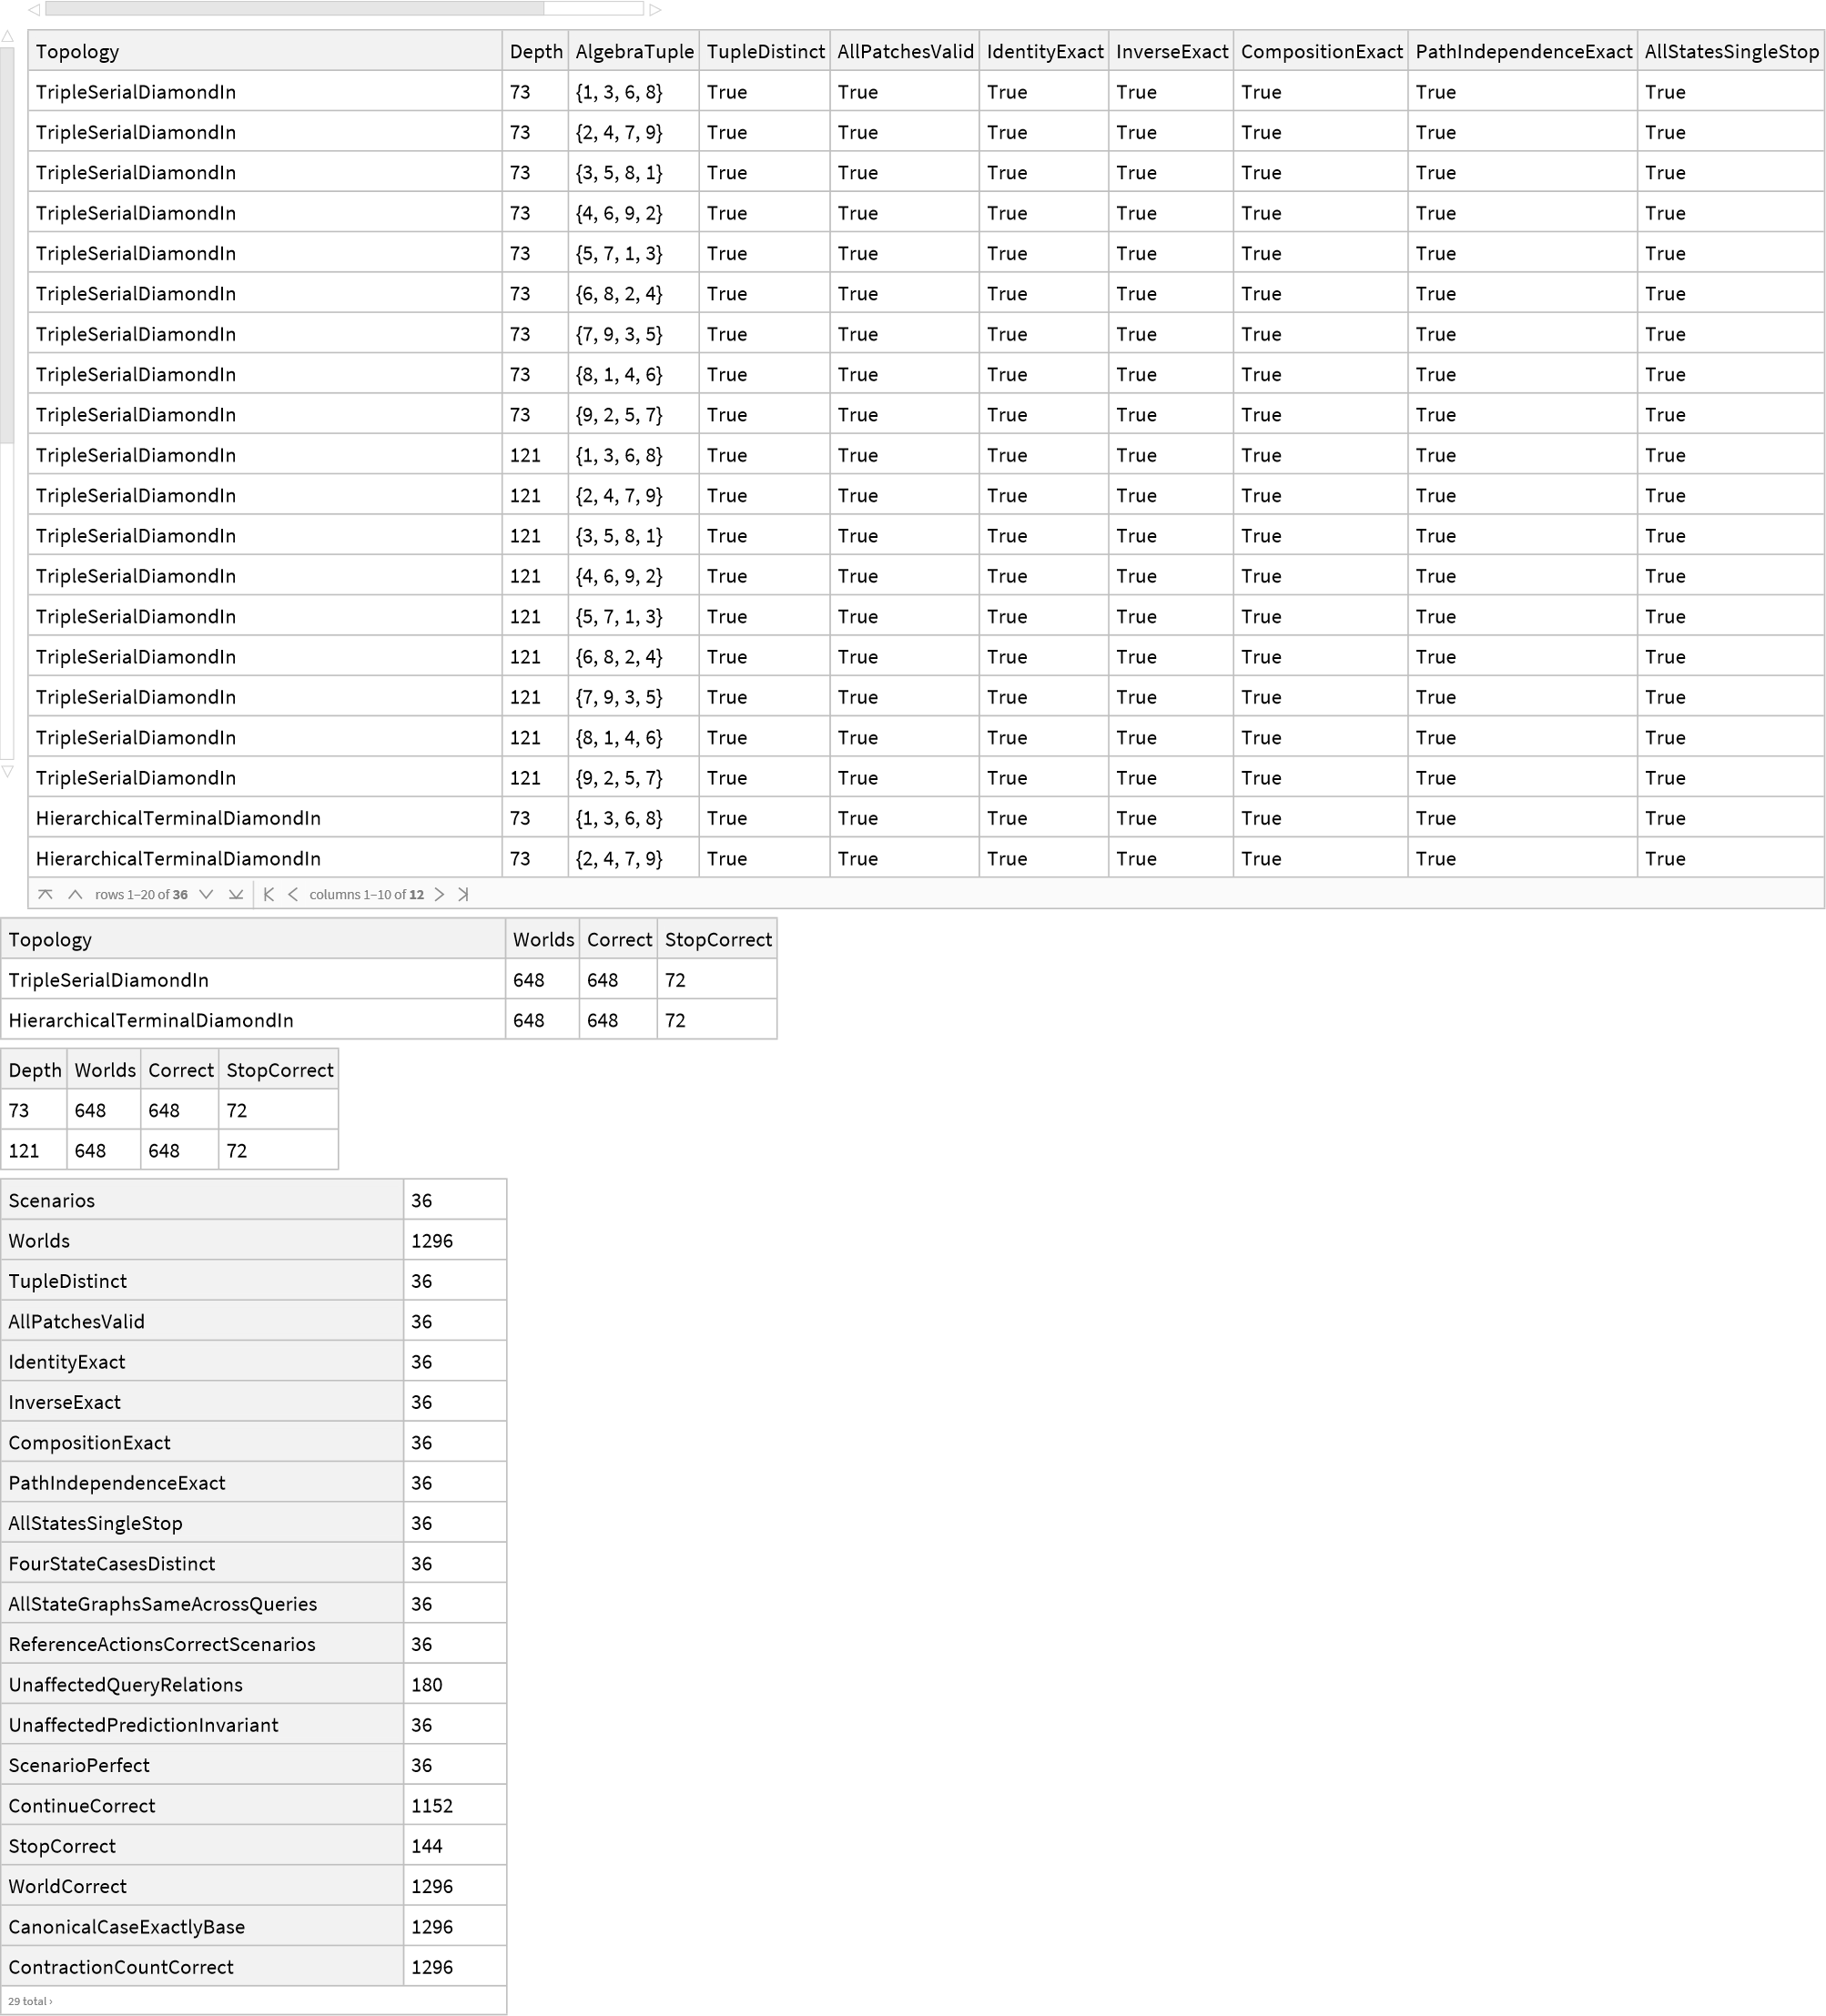

In [739]:
blindScenarios90=Flatten[Table[
PrepareScenario90[topology,depth,tuple],
{topology,blindTopologies90},{depth,blindDepths90},{tuple,blindAlgebraTuples90}
],2];
blindWorlds90=Flatten[Lookup[blindScenarios90,"Worlds"],1];

summary90=<|
"Scenarios"->Length[blindScenarios90],
"Worlds"->Length[blindWorlds90],
"TupleDistinct"->Count[blindScenarios90,s_/;TrueQ[s["TupleDistinct"]]],
"AllPatchesValid"->Count[blindScenarios90,s_/;TrueQ[s["AllPatchesValid"]]],
"IdentityExact"->Count[blindScenarios90,s_/;TrueQ[s["IdentityExact"]]],
"InverseExact"->Count[blindScenarios90,s_/;TrueQ[s["InverseExact"]]],
"CompositionExact"->Count[blindScenarios90,s_/;TrueQ[s["CompositionExact"]]],
"PathIndependenceExact"->Count[blindScenarios90,s_/;TrueQ[s["PathIndependenceExact"]]],
"AllStatesSingleStop"->Count[blindScenarios90,s_/;TrueQ[s["AllStatesSingleStop"]]],
"FourStateCasesDistinct"->Count[blindScenarios90,s_/;TrueQ[s["FourStateCasesDistinct"]]],
"AllStateGraphsSameAcrossQueries"->Count[
blindScenarios90,s_/;TrueQ[s["AllStateGraphsSameAcrossQueries"]]
],
"ReferenceActionsCorrectScenarios"->Count[
blindScenarios90,s_/;TrueQ[s["ReferenceActionsCorrect"]]
],
"UnaffectedQueryRelations"->Total@Lookup[blindScenarios90,"UnaffectedQueryCount"],
"UnaffectedPredictionInvariant"->Count[
blindScenarios90,s_/;TrueQ[s["UnaffectedPredictionInvariant"]]
],
"ScenarioPerfect"->Count[
blindScenarios90,s_/;TrueQ[s["AllThirtySixWorldsCorrect"]]
],
"ContinueCorrect"->Count[
blindWorlds90,w_/;SameQ[w["Target"],"Continue"]&&TrueQ[w["Correct"]]
],
"StopCorrect"->Count[
blindWorlds90,w_/;SameQ[w["Target"],"Stop"]&&TrueQ[w["Correct"]]
],
"WorldCorrect"->Count[blindWorlds90,w_/;TrueQ[w["Correct"]]],
"CanonicalCaseExactlyBase"->Count[
blindWorlds90,w_/;TrueQ[w["CanonicalCaseExactlyBase"]]
],
"ContractionCountCorrect"->Count[
blindWorlds90,w_/;TrueQ[w["ContractionCountCorrect"]]
],
"ProtectedNodesPreserved"->Count[
blindWorlds90,w_/;TrueQ[w["ProtectedNodesPreserved"]]
],
"ReferenceActionsCorrect"->Count[
blindWorlds90,w_/;SameQ[w["ReferenceAction"],w["Target"]]
],
"NonEmptyTokens"->Count[blindWorlds90,w_/;w["RawTokenCount"]>0],
"ValidFeatureVectors"->Count[
blindWorlds90,w_/;VectorQ[w["FeatureVector"],IntegerQ]&&Length[w["FeatureVector"]]===27
],
"PredictionFailures"->Count[blindWorlds90,w_/;SameQ[w["Prediction"],$Failed]],
"TerminatedNaturally"->Count[
blindWorlds90,w_/;TrueQ[w["TerminatedNaturally"]]
],
"HitSafetyCap"->Count[blindWorlds90,w_/;TrueQ[w["HitSafetyCap"]]],
"NineBranchWorlds"->Count[blindWorlds90,w_/;SameQ[w["BranchCount"],9]],
"TotalTraceSeconds"->Total@Lookup[blindWorlds90,"TraceSeconds"]
|>;

byTopology90=Map[Function[topology,Module[{worlds},
worlds=Select[blindWorlds90,SameQ[#1["Topology"],topology]&];
<|"Topology"->topology,"Worlds"->Length[worlds],
"Correct"->Count[worlds,w_/;TrueQ[w["Correct"]]],
"StopCorrect"->Count[worlds,w_/;SameQ[w["Target"],"Stop"]&&TrueQ[w["Correct"]]]|>
]],blindTopologies90];
byDepth90=Map[Function[depth,Module[{worlds},
worlds=Select[blindWorlds90,SameQ[#1["Depth"],depth]&];
<|"Depth"->depth,"Worlds"->Length[worlds],
"Correct"->Count[worlds,w_/;TrueQ[w["Correct"]]],
"StopCorrect"->Count[worlds,w_/;SameQ[w["Target"],"Stop"]&&TrueQ[w["Correct"]]]|>
]],blindDepths90];

Column[{
Dataset[Map[KeyTake[#,{"Topology","Depth","AlgebraTuple","TupleDistinct",
"AllPatchesValid","IdentityExact","InverseExact","CompositionExact",
"PathIndependenceExact","AllStatesSingleStop","UnaffectedPredictionInvariant",
"AllThirtySixWorldsCorrect"}]&,blindScenarios90]],
Dataset[byTopology90],Dataset[byDepth90],Dataset[{summary90}]
}]


Dataset[{<|Stage -> S90, Name -> InterventionAlgebraBlind, 
 
>     CandidateHash -> 703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     CandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     S89CheckpointFileHash -> 
 
>      7d0f543f6f17384ee8969131547b2766aad1fbaed999e5b039c2708d6d89b032, 
 
>     ProtocolHash -> ed241ba2ada54af6e44f9dc009a70f4155767de6994072c7c05e5b75515df518, 
 
>     TestDefinitionHash -> 
 
>      ef31b96fa3a1ff1b4c7f4aec17456d60ec3381eca4df7f6ee8b9bf25f320539c, 
 
>     Depths -> {73, 121}, Topologies -> 
 
>      {TripleSerialDiamondIn, HierarchicalTerminalDiamondIn}, 
 
>     AlgebraTuples -> 
 
>      {{1, 3, 6, 8}, {2, 4, 7, 9}, {3, 5, 8, 1}, {4, 6, 9, 2}, {5, 7, 1, 3}, 
 
>       {6, 8, 2, 4}, {7, 9, 3, 5}, {8, 1, 4, 6}, {9, 2, 5, 7}}, Scenarios -> 36, 
 
>     Worlds -> 1296, ContinueCorrect -> 1152, StopCorrect -> 144, WorldCorrect -> 1296, 
 
>     Accuracy -> 1., BalancedAccuracy -> 1., ScenarioPerfect -> 36, 
 
>     IdentityExact -> 36, InverseExact -> 36, CompositionExact -> 36, 
 
>     PathIndependenceExact -> 36, UnaffectedQueryRelations -> 180, 
 
>     OriginalFrozenModelChanged -> False, OriginalK33CandidateChanged -> False, 
 
>     FrozenDecoderChanged -> False, CoreChanged -> False, 
 
>     CanonicalizerChanged -> False, InterventionCoreChanged -> False, 
 
>     TopologyPrimitivesChanged -> False, FeatureRuntimeChanged -> False, 
 
>     TestDefinitionChangedDuringRun -> False, ProtocolChangedDuringRun -> False, 
 
>     DeduplicationMechanismChanged -> False, ObservationAggregationChanged -> False, 
 
>     S89CheckpointChanged -> False, TestValidityPassed -> True, BlindPerfect -> True, 
 
>     CandidateFrozenBeforeS90 -> True, BlindProtocolHashedBeforeCases -> True, 
 
>     S87DDecoderUsed -> True, S89CheckpointLocked -> True, TrainingRun -> False, 
 
>     CandidateSearchRun -> False, DecoderEditApplied -> False, 
 
>     RetuningApplied -> False, HistoricalBlindTestsRerun -> False, 
 
>     AllNineQueryPositionsTestedPerState -> True, 
 
>     S90IsBlindInterventionAlgebraTest -> True, 
 
>     MayClaimBlindInterventionAlgebraConsistency -> True, 
 
>     MayClaimGeneralCounterfactualReasoning -> False, MayClaimCausalDiscovery -> False, 
 
>     TotalTraceSeconds -> 2403.65, 
 
>     BlindResultHash -> 
 
>      672348fca8ea249461f8fc3b3da2594940ad147346025b9321650b1fc39c5a2c, 
 
>     Outcome -> S90_BLIND_INTERVENTION_ALGEBRA_PASS, 
 
>     SuggestedNextStage -> S91_BASELINE_AND_ABLATION_BENCHMARK|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 56], 
 
>    1], <||>]
Dataset[{<|CertificateExported -> True, 
 
>     CertificatePath -> E:/engine_wolf/TCCT_S90_BlindResultCertificate.json, 
 
>     CertificateFileHash -> 
 
>      0e8c9df9e63ea68d59226416de33243440ef4b84a007be0812b2970ed53deb30|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{CertificateExported, CertificatePath, 
 
>      CertificateFileHash}, {TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[String]}], 1], <||>]
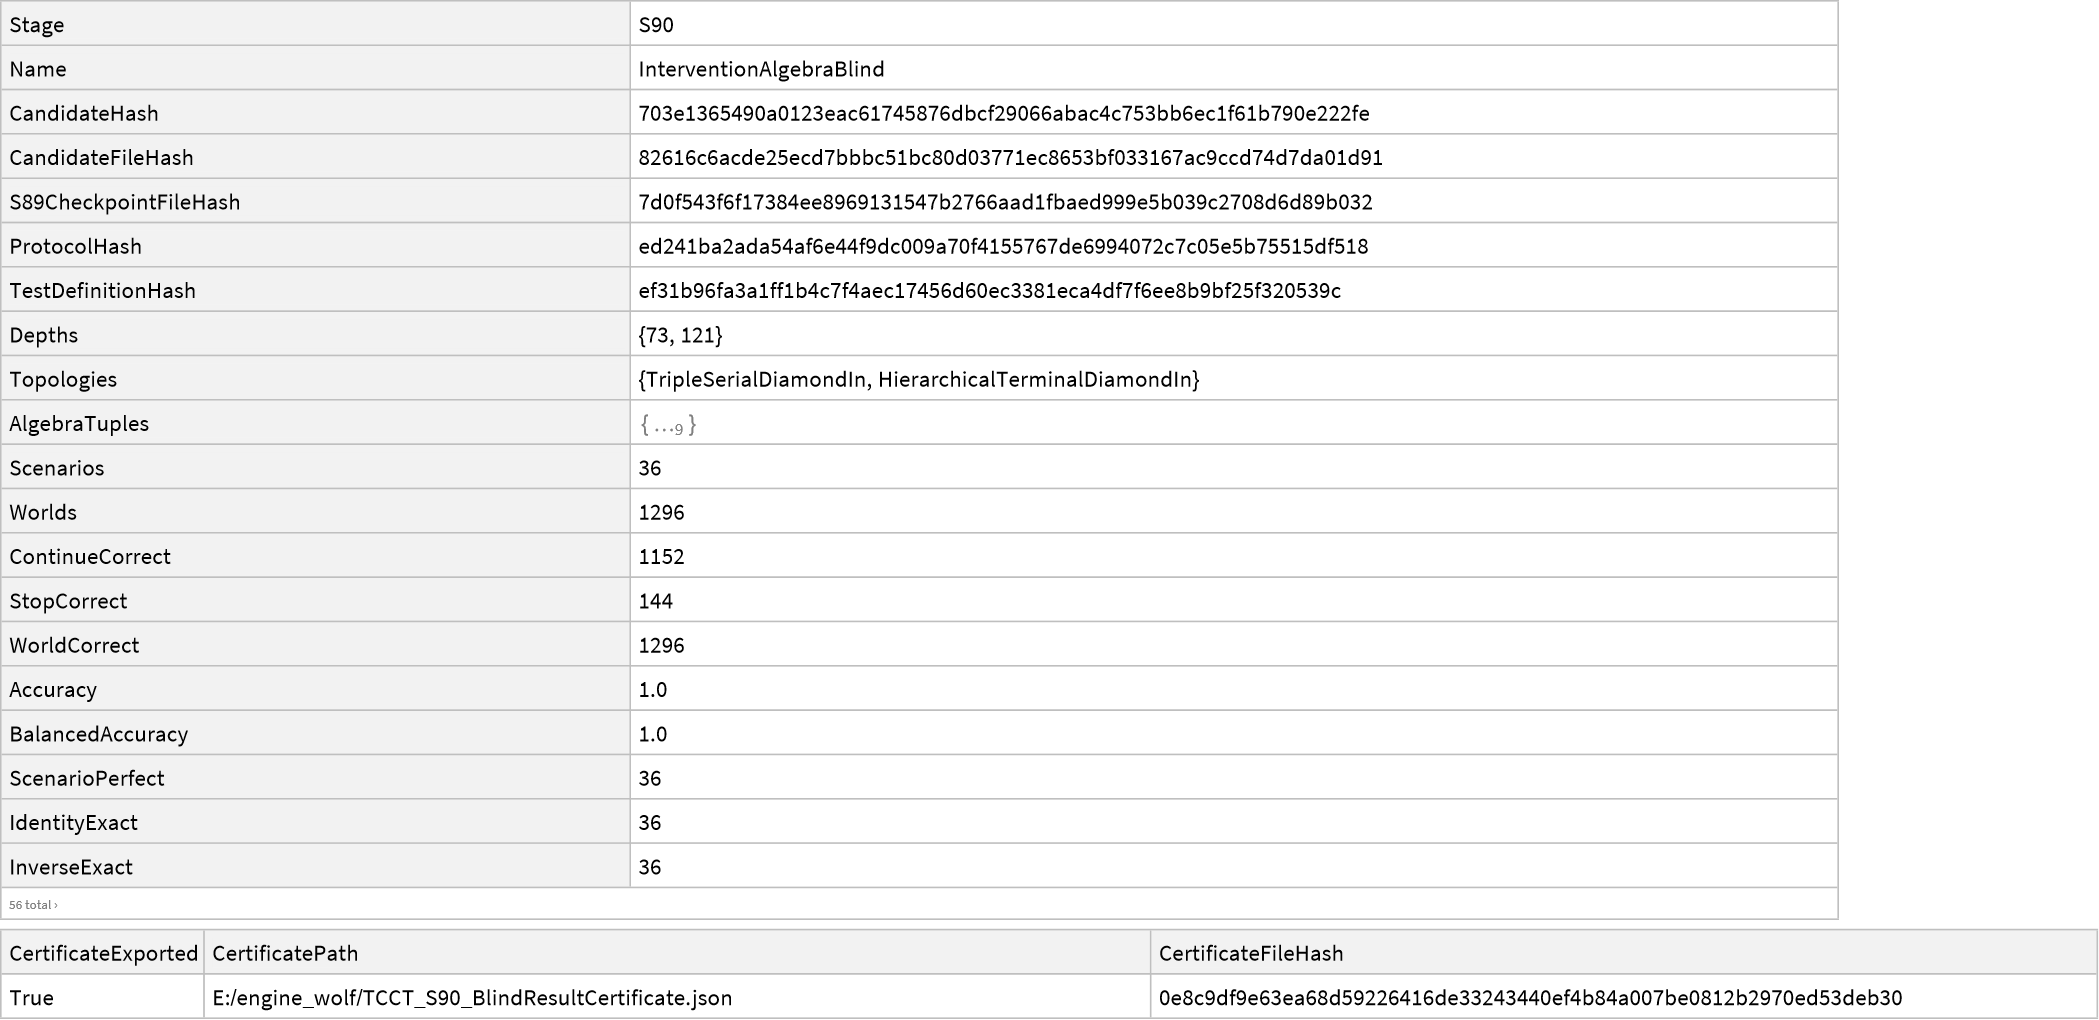

In [745]:
modelHashAfter90=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashAfter90=Hash[Normal[frozenCandidate86E],"SHA256","HexString"];
decoderObjectHashAfter90=Hash[Normal[KeyDrop[frozenDecoderLoaded90,{"Classifier"}]],"SHA256","HexString"];
coreHashAfter90=Hash[CoreDefinitionBundle90[],"SHA256","HexString"];
canonicalizerHashAfter90=Hash[{DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],DownValues[CanonicalCase79B]},"SHA256","HexString"];
interventionHashAfter90=Hash[{DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]},"SHA256","HexString"];
topologyPrimitiveHashAfter90=Hash[{DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],DownValues[HierarchicalDiamondIn80]},"SHA256","HexString"];
decoderRuntimeDefinitionHashAfter90=Hash[TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"];
testDefinitionHashAfter90=Hash[S90TestDefinitionBundle[],"SHA256","HexString"];
protocolHashAfter90=Hash[Normal[protocol90],"SHA256","HexString"];
k33CandidateFileHashAfter90=FileSHA256Hex90[k33CandidatePath90];
decoderRuntimeFileHashAfter90=FileSHA256Hex90[decoderRuntimePath90];
decoderCandidateFileHashAfter90=FileSHA256Hex90[decoderCandidatePath90];
freezeCertificateFileHashAfter90=FileSHA256Hex90[freezeCertificatePath90];
s89CheckpointFileHashAfter90=FileSHA256Hex90[s89CheckpointPath90];

originalFrozenModelUnchanged90=SameQ[modelHashBefore90,modelHashAfter90,expectedFrozenModelHash90];
k33CandidateUnchanged90=And[SameQ[k33ObjectHashBefore90,k33ObjectHashAfter90],
SameQ[k33ObjectHashAfter90,expectedK33CandidateHash90],
SameQ[k33CandidateFileHashBefore90,k33CandidateFileHashAfter90],
SameQ[k33CandidateFileHashAfter90,expectedK33CandidateFileHash90]];
frozenDecoderUnchanged90=And[SameQ[decoderObjectHashBefore90,decoderObjectHashAfter90],
SameQ[decoderCandidateHashLoaded90,expectedDecoderCandidateHash90],
SameQ[decoderCandidateFileHashBefore90,decoderCandidateFileHashAfter90],
SameQ[decoderCandidateFileHashAfter90,expectedDecoderCandidateFileHash90]];
coreUnchanged90=SameQ[coreHashBefore90,coreHashAfter90];
canonicalizerUnchanged90=SameQ[canonicalizerHashBefore90,canonicalizerHashAfter90];
interventionCoreUnchanged90=SameQ[interventionHashBefore90,interventionHashAfter90];
topologyPrimitivesUnchanged90=SameQ[topologyPrimitiveHashBefore90,topologyPrimitiveHashAfter90];
decoderRuntimeUnchanged90=And[
SameQ[decoderRuntimeDefinitionHashBefore90,decoderRuntimeDefinitionHashAfter90],
SameQ[decoderRuntimeFileHashBefore90,decoderRuntimeFileHashAfter90],
SameQ[decoderRuntimeFileHashAfter90,expectedFeatureRuntimeFileHash90]];
testDefinitionUnchanged90=SameQ[testDefinitionHashBefore90,testDefinitionHashAfter90];
protocolUnchanged90=SameQ[protocolHash90,protocolHashAfter90];
freezeCertificateUnchanged90=And[
SameQ[freezeCertificateFileHashBefore90,freezeCertificateFileHashAfter90],
SameQ[freezeCertificateFileHashAfter90,expectedFreezeCertificateFileHash90]];
s89CheckpointUnchanged90=And[
SameQ[s89CheckpointFileHashBefore90,s89CheckpointFileHashAfter90],
SameQ[s89CheckpointFileHashAfter90,expectedS89CheckpointFileHash90]];
observationAggregationUnchanged90=SameQ[protocol90["ObservationAggregation"],
"FullQueriedObservationMultisetWithoutCodeDeduplication"];

testValidityPassed90=And[TrueQ[preflightPassed90],
TrueQ[originalFrozenModelUnchanged90],TrueQ[k33CandidateUnchanged90],
TrueQ[frozenDecoderUnchanged90],TrueQ[coreUnchanged90],
TrueQ[canonicalizerUnchanged90],TrueQ[interventionCoreUnchanged90],
TrueQ[topologyPrimitivesUnchanged90],TrueQ[decoderRuntimeUnchanged90],
TrueQ[testDefinitionUnchanged90],TrueQ[protocolUnchanged90],
TrueQ[freezeCertificateUnchanged90],TrueQ[s89CheckpointUnchanged90],
TrueQ[observationAggregationUnchanged90],
TrueQ[protocol90["NoCaseEvaluatedBeforeProtocolHash"]],
SameQ[summary90["Scenarios"],36],SameQ[summary90["Worlds"],1296],
SameQ[summary90["TupleDistinct"],36],SameQ[summary90["AllPatchesValid"],36],
SameQ[summary90["IdentityExact"],36],SameQ[summary90["InverseExact"],36],
SameQ[summary90["CompositionExact"],36],SameQ[summary90["PathIndependenceExact"],36],
SameQ[summary90["AllStatesSingleStop"],36],
SameQ[summary90["FourStateCasesDistinct"],36],
SameQ[summary90["AllStateGraphsSameAcrossQueries"],36],
SameQ[summary90["ReferenceActionsCorrectScenarios"],36],
SameQ[summary90["UnaffectedQueryRelations"],180],
SameQ[summary90["UnaffectedPredictionInvariant"],36],
SameQ[summary90["CanonicalCaseExactlyBase"],1296],
SameQ[summary90["ContractionCountCorrect"],1296],
SameQ[summary90["ProtectedNodesPreserved"],1296],
SameQ[summary90["ReferenceActionsCorrect"],1296],
SameQ[summary90["NonEmptyTokens"],1296],SameQ[summary90["ValidFeatureVectors"],1296],
SameQ[summary90["PredictionFailures"],0],SameQ[summary90["TerminatedNaturally"],1296],
SameQ[summary90["HitSafetyCap"],0],SameQ[summary90["NineBranchWorlds"],1296]];

blindPerfect90=And[TrueQ[testValidityPassed90],
SameQ[summary90["ContinueCorrect"],1152],SameQ[summary90["StopCorrect"],144],
SameQ[summary90["WorldCorrect"],1296],SameQ[summary90["ScenarioPerfect"],36]];
accuracy90=N[summary90["WorldCorrect"]/1296];
balancedAccuracy90=N@Mean[{summary90["ContinueCorrect"]/1152,summary90["StopCorrect"]/144}];
resultPayload90=<|"Stage"->"S90","Name"->"InterventionAlgebraBlind",
"CandidateHash"->decoderCandidateHashLoaded90,
"CandidateFileHash"->decoderCandidateFileHashAfter90,
"S89CheckpointFileHash"->s89CheckpointFileHashAfter90,
"ProtocolHash"->protocolHashAfter90,"TestDefinitionHash"->testDefinitionHashAfter90,
"Depths"->blindDepths90,"Topologies"->blindTopologies90,
"AlgebraTuples"->blindAlgebraTuples90,"Scenarios"->summary90["Scenarios"],
"Worlds"->summary90["Worlds"],"ContinueCorrect"->summary90["ContinueCorrect"],
"StopCorrect"->summary90["StopCorrect"],"WorldCorrect"->summary90["WorldCorrect"],
"Accuracy"->accuracy90,"BalancedAccuracy"->balancedAccuracy90,
"ScenarioPerfect"->summary90["ScenarioPerfect"],
"IdentityExact"->summary90["IdentityExact"],"InverseExact"->summary90["InverseExact"],
"CompositionExact"->summary90["CompositionExact"],
"PathIndependenceExact"->summary90["PathIndependenceExact"],
"UnaffectedQueryRelations"->summary90["UnaffectedQueryRelations"],
"OriginalFrozenModelChanged"->!TrueQ[originalFrozenModelUnchanged90],
"OriginalK33CandidateChanged"->!TrueQ[k33CandidateUnchanged90],
"FrozenDecoderChanged"->!TrueQ[frozenDecoderUnchanged90],
"CoreChanged"->!TrueQ[coreUnchanged90],
"CanonicalizerChanged"->!TrueQ[canonicalizerUnchanged90],
"InterventionCoreChanged"->!TrueQ[interventionCoreUnchanged90],
"TopologyPrimitivesChanged"->!TrueQ[topologyPrimitivesUnchanged90],
"FeatureRuntimeChanged"->!TrueQ[decoderRuntimeUnchanged90],
"TestDefinitionChangedDuringRun"->!TrueQ[testDefinitionUnchanged90],
"ProtocolChangedDuringRun"->!TrueQ[protocolUnchanged90],
"DeduplicationMechanismChanged"->!TrueQ[coreUnchanged90],
"ObservationAggregationChanged"->!TrueQ[observationAggregationUnchanged90],
"S89CheckpointChanged"->!TrueQ[s89CheckpointUnchanged90],
"TestValidityPassed"->testValidityPassed90,"BlindPerfect"->blindPerfect90|>;
blindResultHash90=Hash[Normal[resultPayload90],"SHA256","HexString"];
cert90=Join[resultPayload90,<|
"CandidateFrozenBeforeS90"->True,"BlindProtocolHashedBeforeCases"->True,
"S87DDecoderUsed"->True,"S89CheckpointLocked"->True,
"TrainingRun"->False,"CandidateSearchRun"->False,
"DecoderEditApplied"->False,"RetuningApplied"->False,
"HistoricalBlindTestsRerun"->False,"AllNineQueryPositionsTestedPerState"->True,
"S90IsBlindInterventionAlgebraTest"->True,
"MayClaimBlindInterventionAlgebraConsistency"->blindPerfect90,
"MayClaimGeneralCounterfactualReasoning"->False,"MayClaimCausalDiscovery"->False,
"TotalTraceSeconds"->summary90["TotalTraceSeconds"],"BlindResultHash"->blindResultHash90,
"Outcome"->Which[!TrueQ[testValidityPassed90],"INVALID_S90_BLIND_TEST",
TrueQ[blindPerfect90],"S90_BLIND_INTERVENTION_ALGEBRA_PASS",
True,"S90_VALID_BLIND_FAILURE_DO_NOT_RETUNE"],
"SuggestedNextStage"->Which[!TrueQ[testValidityPassed90],
"S90R_REPAIR_HARNESS_WITHOUT_MODEL_CHANGE",TrueQ[blindPerfect90],
"S91_BASELINE_AND_ABLATION_BENCHMARK",True,"S90A_FAILURE_AUDIT_WITHOUT_RETUNING"]|>];
certificateExportResult90=Quiet@Check[
Export[s90ResultCertificatePath,cert90,"RawJSON"],$Failed];
certificateExported90=And[StringQ[certificateExportResult90],FileExistsQ[s90ResultCertificatePath]];
Column[{Dataset[{cert90}],Dataset[{<|"CertificateExported"->certificateExported90,
"CertificatePath"->s90ResultCertificatePath,"CertificateFileHash"->If[
certificateExported90,FileSHA256Hex90[s90ResultCertificatePath],Missing[]]|>}]}]
